# 🛍️ Shopping Mall Customer Segmentation
## Comparison — All Methods
### K-Means vs MeanShift vs DBSCAN vs Autoencoder

---
### 📌 What does this notebook do?
After all members have run their individual notebooks, we bring together
all results and compare them using:
1. **Silhouette Score** — how well-separated the clusters are
2. **Davies-Bouldin Index** — how compact and separate clusters are
3. **Side-by-side 3D plots** — visual comparison
4. **Best algorithm selection** → used for Streamlit UI

> ⚠️ Run ALL member notebooks first (01, 02, 03, 04)!

---
## Step 1: Load All Results

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    v_measure_score, homogeneity_score, completeness_score
)
import pickle
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

X_scaled = np.load('data/X_scaled.npy')
df_clean = pd.read_csv('data/data_preprocessed.csv')
df       = pd.read_csv('data/Shopping_Mall_Customer_Segmentation_Data_.csv')

# Load scores from each member's notebook
h_scores   = pickle.load(open('data/hierarchical_scores.pkl', 'rb'))
gmm_scores = pickle.load(open('data/gmm_scores.pkl', 'rb'))
ae_scores  = pickle.load(open('data/autoencoder_scores.pkl', 'rb'))

# Load cluster labels
h_labels   = pickle.load(open('data/hierarchical_labels.pkl', 'rb'))
gmm_labels = pickle.load(open('data/gmm_labels.pkl', 'rb'))
ae_labels  = pickle.load(open('data/autoencoder_labels.pkl', 'rb'))

print('✅ All results loaded!')
print(f'   Hierarchical : {h_scores["n_clusters"]} clusters')
print(f'   GMM          : {gmm_scores["n_clusters"]} clusters')
print(f'   Autoencoder  : {ae_scores["n_clusters"]} clusters')

✅ All results loaded!
   Hierarchical : 5 clusters
   GMM          : 8 clusters
   Autoencoder  : 3 clusters


---
## Step 2: Metrics Comparison Table

### 📌 How to read this table:
| Metric | What it measures | Winner |
|--------|-----------------|--------|
| Silhouette Score | How well clusters are separated (0–1) | **Highest** |
| Davies-Bouldin | Cluster compactness vs separation | **Lowest** |
| Noise Points | Customers not assigned to any cluster | Lower |
| No. Clusters | Number of groups found | Depends on context |

In [8]:
comparison_df = pd.DataFrame([
    {
        'Algorithm': h_scores['algorithm'],
        'Clusters': h_scores['n_clusters'],
        'Silhouette': h_scores['silhouette'],
        'Davies-Bouldin': h_scores['davies_bouldin'],
        'Noise': h_scores['noise']
    },
    {
        'Algorithm': gmm_scores['algorithm'],
        'Clusters': gmm_scores['n_clusters'],
        'Silhouette': gmm_scores['silhouette'],
        'Davies-Bouldin': gmm_scores['davies_bouldin'],
        'Noise': gmm_scores['noise']
    },
    {
        'Algorithm': ae_scores['algorithm'],
        'Clusters': ae_scores['n_clusters'],
        'Silhouette': ae_scores['silhouette'],
        'Davies-Bouldin': ae_scores['davies_bouldin'],
        'Noise': ae_scores['noise']
    }
])

print('\n=== Comparison Table ===')
print(comparison_df.to_string(index=False))


=== Comparison Table ===
             Algorithm  Clusters  Silhouette  Davies-Bouldin  Noise
HierarchicalClustering         5      0.1930          1.1875      0
                   GMM         8      0.2796          0.9777      0
    Autoencoder+KMeans         3      0.5346          0.6633      0


---
## Step 3: Metric Bar Charts — Silhouette & Davies-Bouldin

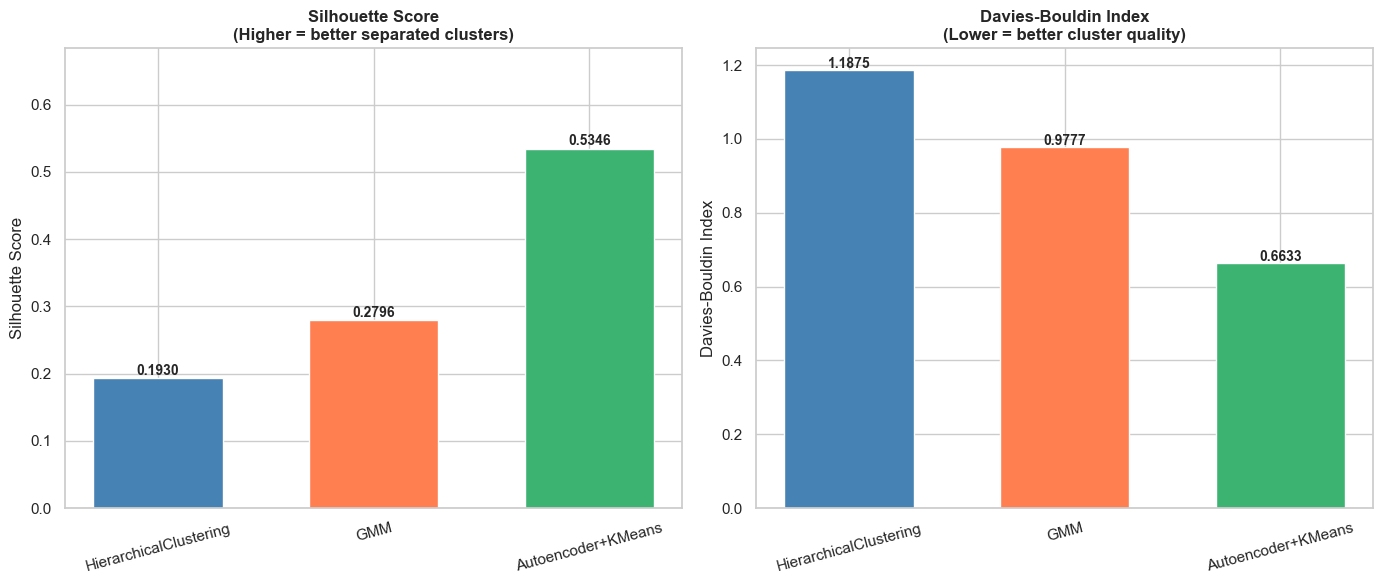

In [9]:
all_scores = [h_scores, gmm_scores, ae_scores]

algos    = [s['algorithm']      for s in all_scores]
sil_vals = [s['silhouette']     for s in all_scores]
dbs_vals = [s['davies_bouldin'] for s in all_scores]

# 3 algorithms only
bar_cols = ['steelblue', 'coral', 'mediumseagreen']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Silhouette
bars1 = axes[0].bar(algos, sil_vals, color=bar_cols, edgecolor='white', width=0.6)
for bar, val in zip(bars1, sil_vals):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{val:.4f}',
        ha='center',
        fontweight='bold',
        fontsize=10
    )

axes[0].set_title('Silhouette Score\n(Higher = better separated clusters)', fontweight='bold')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_ylim(0, max(sil_vals) + 0.15)
axes[0].tick_params(axis='x', rotation=15)

# Davies-Bouldin
bars2 = axes[1].bar(algos, dbs_vals, color=bar_cols, edgecolor='white', width=0.6)
for bar, val in zip(bars2, dbs_vals):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{val:.4f}',
        ha='center',
        fontweight='bold',
        fontsize=10
    )

axes[1].set_title('Davies-Bouldin Index\n(Lower = better cluster quality)', fontweight='bold')
axes[1].set_ylabel('Davies-Bouldin Index')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('data/comparison_metrics.png', bbox_inches='tight')
plt.show()

---
## Step 5: Side-by-Side 3D Cluster Plots

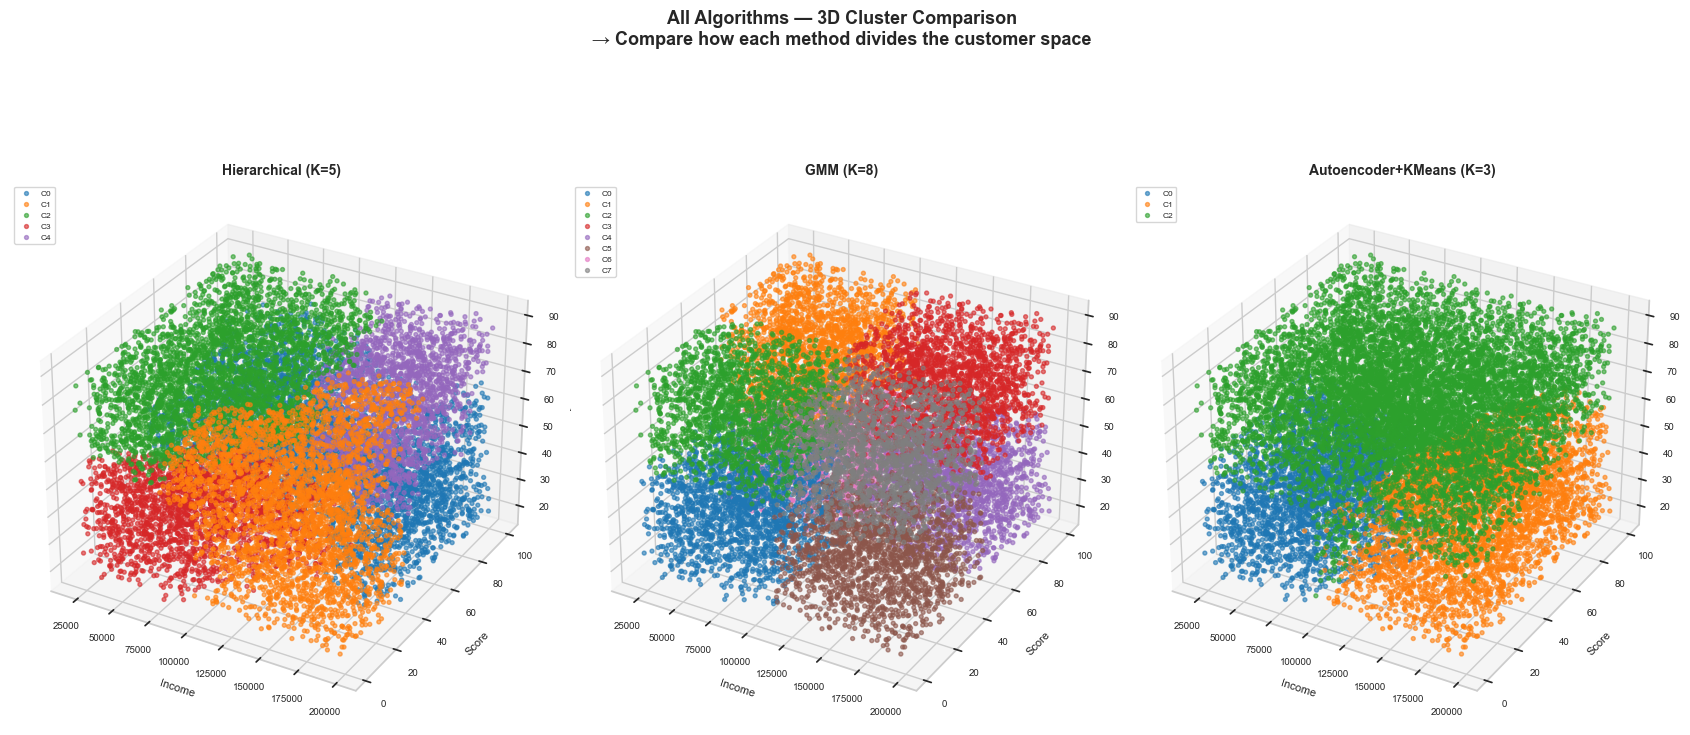

In [10]:
all_labels = [h_labels, gmm_labels, ae_labels]
all_titles = [
    f'Hierarchical (K={h_scores["n_clusters"]})',
    f'GMM (K={gmm_scores["n_clusters"]})',
    f'Autoencoder+KMeans (K={ae_scores["n_clusters"]})'
]

fig = plt.figure(figsize=(17, 8))

for idx, (labels, title) in enumerate(zip(all_labels, all_titles)):
    ax = fig.add_subplot(1, 3, idx + 1, projection='3d')

    unique = sorted(set(labels))
    n_c = len(unique) - (1 if -1 in unique else 0)
    pal = sns.color_palette('tab10', n_c)
    c_map = {c: pal[i] for i, c in enumerate(l for l in unique if l != -1)}

    # Noise points (normally none for H / GMM / AE+KMeans, but keep safe)
    if -1 in unique:
        nm = labels == -1
        ax.scatter(
            df.loc[nm, 'Annual Income'],
            df.loc[nm, 'Spending Score'],
            df.loc[nm, 'Age'],
            c='lightgray', s=8, alpha=0.3, marker='x', label='Noise'
        )

    for c in unique:
        if c == -1:
            continue
        mask = labels == c
        ax.scatter(
            df.loc[mask, 'Annual Income'],
            df.loc[mask, 'Spending Score'],
            df.loc[mask, 'Age'],
            color=c_map[c], s=8, alpha=0.6, label=f'C{c}'
        )

    ax.set_xlabel('Income', fontsize=8)
    ax.set_ylabel('Score', fontsize=8)
    ax.set_zlabel('Age', fontsize=8)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=6, loc='upper left')

plt.suptitle(
    'All Algorithms — 3D Cluster Comparison\n→ Compare how each method divides the customer space',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('data/comparison_3d_all.png', bbox_inches='tight')
plt.show()

---
## Step 6: Final Summary & Best Algorithm Decision

In [11]:
display_df = pd.DataFrame([
    {
        'Algorithm': h_scores['algorithm'],
        'Clusters': h_scores['n_clusters'],
        'Silhouette': h_scores['silhouette'],
        'Davies-Bouldin': h_scores['davies_bouldin']
    },
    {
        'Algorithm': gmm_scores['algorithm'],
        'Clusters': gmm_scores['n_clusters'],
        'Silhouette': gmm_scores['silhouette'],
        'Davies-Bouldin': gmm_scores['davies_bouldin']
    },
    {
        'Algorithm': ae_scores['algorithm'],
        'Clusters': ae_scores['n_clusters'],
        'Silhouette': ae_scores['silhouette'],
        'Davies-Bouldin': ae_scores['davies_bouldin']
    }
])

best_sil = algos[sil_vals.index(max(sil_vals))]
best_dbs = algos[dbs_vals.index(min(dbs_vals))]

print('=' * 70)
print('                    FINAL SUMMARY')
print('=' * 70)
print(display_df.to_string(index=False))
print('=' * 70)
print()
print(f'🏆 Best Silhouette Score : {best_sil}')
print(f'🏆 Best Davies-Bouldin   : {best_dbs}')
print()
print('Algorithm Characteristics:')
print('Algorithm Characteristics:')
print('  Hierarchical Clustering : No need K initially (can use dendrogram). Interpretable. Good for small–medium datasets.')
print('  GMM (Gaussian Mixture)  : Probabilistic clustering. Handles overlapping clusters. Uses BIC/AIC to select K.')
print('  Autoencoder + KMeans    : Deep learning + clustering. Learns better feature representation (dimensionality reduction).')
print()
overall_best = best_sil  # Change if dbi gives a different winner
print(f'→ SELECTED BEST ALGORITHM: {overall_best}')
print(f'→ This algorithm will be used for the Streamlit UI (app.py)')

                    FINAL SUMMARY
             Algorithm  Clusters  Silhouette  Davies-Bouldin
HierarchicalClustering         5      0.1930          1.1875
                   GMM         8      0.2796          0.9777
    Autoencoder+KMeans         3      0.5346          0.6633

🏆 Best Silhouette Score : Autoencoder+KMeans
🏆 Best Davies-Bouldin   : Autoencoder+KMeans

Algorithm Characteristics:
Algorithm Characteristics:
  Hierarchical Clustering : No need K initially (can use dendrogram). Interpretable. Good for small–medium datasets.
  GMM (Gaussian Mixture)  : Probabilistic clustering. Handles overlapping clusters. Uses BIC/AIC to select K.
  Autoencoder + KMeans    : Deep learning + clustering. Learns better feature representation (dimensionality reduction).

→ SELECTED BEST ALGORITHM: Autoencoder+KMeans
→ This algorithm will be used for the Streamlit UI (app.py)
